In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import math
import pickle

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# from fix_data_leakage import scale_data_without_leakage, create_sequences
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [2]:
# df = pd.read_csv("E:\Document\PROJECT\data\processed\data2225_done.csv")
# df = pd.read_csv("data/processed/data2225_done.csv")


df = pd.read_csv('/content/data2225_done.csv')
df.head()

,Local Time,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed,IsHoliday,Accumulated Hours of Rain
0,2022-01-13 07:00:00,353.1,10.0,84.0,98.0,17.08,52.0,100,0.00,1020,95.0,15.5,0.6,2.00,False,0
1,2022-01-13 08:00:00,343.5,9.0,87.3,95.7,16.75,48.7,91,0.00,1021,94.0,15.4,0.7,2.33,False,0
2,2022-01-13 09:00:00,334.0,8.0,90.7,93.3,16.42,45.3,83,0.50,1022,93.0,15.3,1.0,2.66,False,1
3,2022-01-13 10:00:00,324.5,7.0,94.0,91.0,16.09,42.0,75,0.75,1022,93.0,15.2,1.5,3.00,False,2
4,2022-01-13 11:00:00,319.6,6.7,95.7,91.3,16.17,39.0,83,0.00,1021,87.0,15.6,1.9,3.00,False,0


In [3]:
df['Local Time'] = pd.to_datetime(df['Local Time'])
df = df.set_index('Local Time').sort_index()

agg_map = {col: "mean" for col in df.columns}
if "IsHoliday" in agg_map:
    agg_map["IsHoliday"] = "max"

df = df.resample("3H").agg(agg_map).dropna().copy()

/tmp/ipykernel_6653/4140810184.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.resample("3H").agg(agg_map).dropna().copy()


In [4]:
# ===== Time features =====
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek   # Monday=0, Sunday=6
df["month"] = df.index.month

# ===== PM25 lag features =====
df["PM25_lag_1"] = df["PM25"].shift(1)
df["PM25_lag_8"] = df["PM25"].shift(8)
df["PM25_lag_24"] = df["PM25"].shift(24)

# bỏ các dòng đầu bị NaN do lag/rolling
df = df.dropna().copy()

print(df[[
    "PM25", "PM25_lag_1", "PM25_lag_8", "PM25_lag_24",
    "hour", "dayofweek", "month"
]].head())

                          PM25  PM25_lag_1  PM25_lag_8  PM25_lag_24  hour  \
Local Time                                                                  
2022-01-16 06:00:00  19.800000   24.063333   34.403333    16.915000     6   
2022-01-16 09:00:00  11.303333   19.800000   18.340000    16.226667     9   
2022-01-16 12:00:00   9.020000   11.303333   10.310000    16.280000    12   
2022-01-16 15:00:00  11.686667    9.020000   13.583333    16.583333    15   
2022-01-16 18:00:00  12.926667   11.686667   21.066667    20.406667    18   

                     dayofweek  month  
Local Time                             
2022-01-16 06:00:00          6      1  
2022-01-16 09:00:00          6      1  
2022-01-16 12:00:00          6      1  
2022-01-16 15:00:00          6      1  
2022-01-16 18:00:00          6      1  


In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns

skew_df = pd.DataFrame({
    "skew": df[num_cols].skew(numeric_only=True),
    "mean": df[num_cols].mean(numeric_only=True),
    "median": df[num_cols].median(numeric_only=True),
    "min": df[num_cols].min(numeric_only=True),
    "max": df[num_cols].max(numeric_only=True)
}).sort_values("skew", ascending=False)

print(skew_df)

                               skew         mean       median         min  \
Precipitation              5.992642     0.308929     0.000000    0.000000   
Accumulated Hours of Rain  5.780818     1.287799     0.000000    0.000000   
PM10                       4.776306    42.596196    30.933333    0.620000   
IsHoliday                  4.465862     0.043681     0.000000    0.000000   
SO2                        4.053063    36.267982    29.450000    0.166667   
NO2                        3.831239    18.323502    11.540000    0.100000   
CO                         3.315090   523.541938   200.533333   10.000000   
PM25_lag_24                2.543011    21.103650    16.686667    0.480000   
PM25_lag_8                 2.541773    21.107713    16.693333    0.480000   
PM25_lag_1                 2.536982    21.130055    16.713333    0.480000   
PM25                       2.536391    21.131560    16.713333    0.480000   
UV Index                   1.883224     1.308482     0.466667    0.000000   

In [6]:
skew_df["abs_skew"] = skew_df["skew"].abs()

strong_skew = skew_df[skew_df["abs_skew"] >= 1].sort_values("abs_skew", ascending=False)
moderate_skew = skew_df[(skew_df["abs_skew"] >= 0.5) & (skew_df["abs_skew"] < 1)]

print("=== Cột lệch mạnh ===")
print(strong_skew[["skew", "mean", "median", "min", "max"]])

print("\n=== Cột lệch vừa ===")
print(moderate_skew[["skew", "mean", "median", "min", "max"]])

=== Cột lệch mạnh ===
                               skew        mean      median        min  \
Precipitation              5.992642    0.308929    0.000000   0.000000   
Accumulated Hours of Rain  5.780818    1.287799    0.000000   0.000000   
PM10                       4.776306   42.596196   30.933333   0.620000   
IsHoliday                  4.465862    0.043681    0.000000   0.000000   
SO2                        4.053063   36.267982   29.450000   0.166667   
NO2                        3.831239   18.323502   11.540000   0.100000   
CO                         3.315090  523.541938  200.533333  10.000000   
PM25_lag_24                2.543011   21.103650   16.686667   0.480000   
PM25_lag_8                 2.541773   21.107713   16.693333   0.480000   
PM25_lag_1                 2.536982   21.130055   16.713333   0.480000   
PM25                       2.536391   21.131560   16.713333   0.480000   
UV Index                   1.883224    1.308482    0.466667   0.000000   
O3              

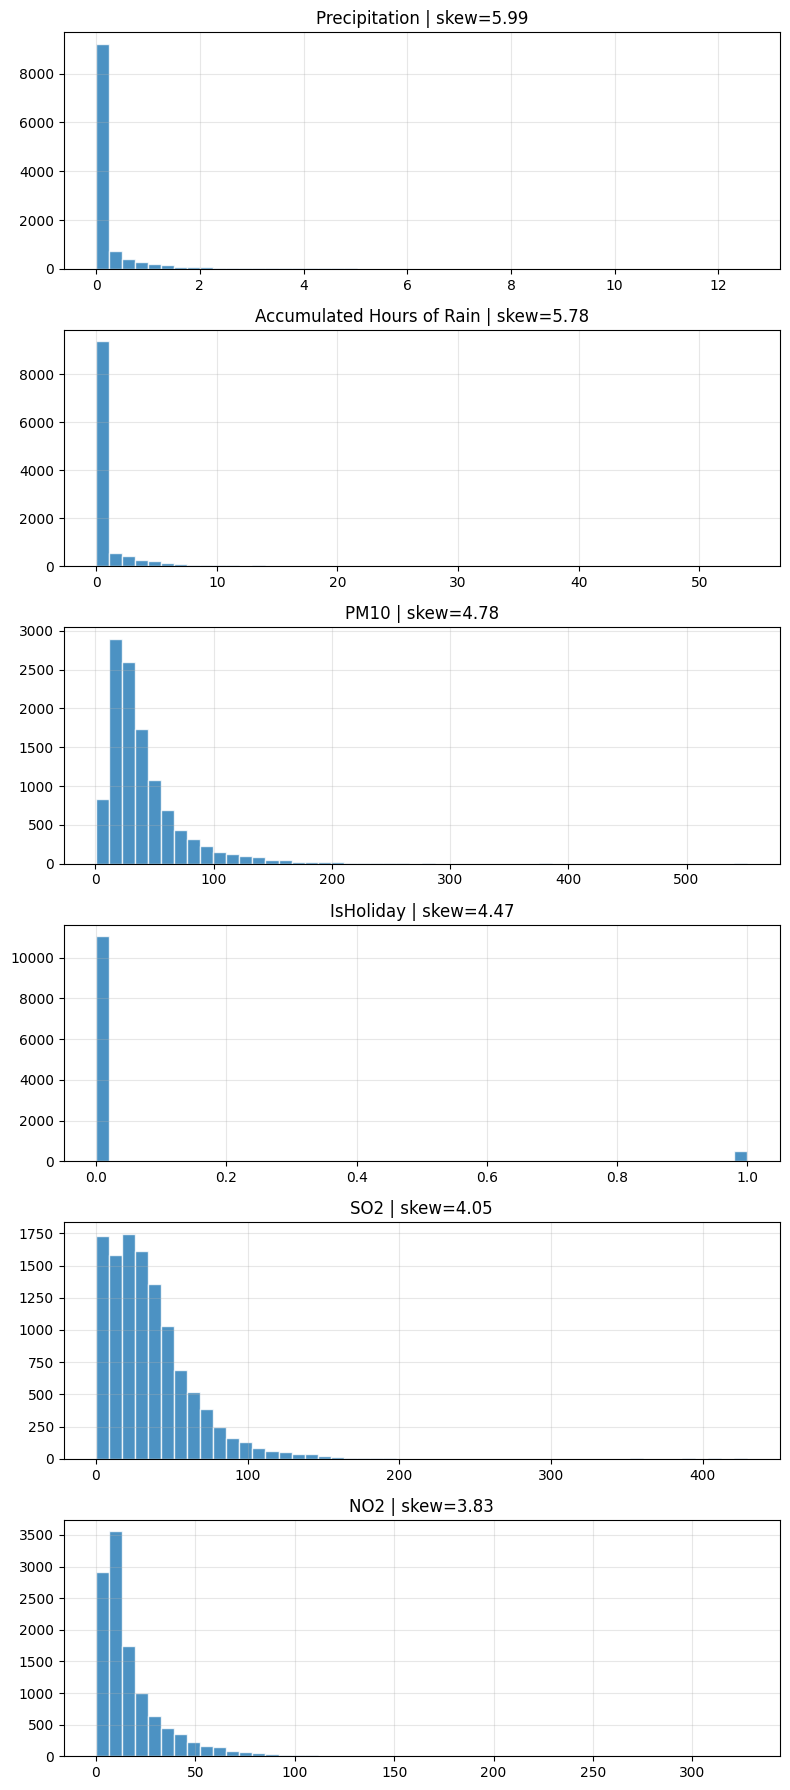

In [7]:
cols_to_plot = strong_skew.index.tolist()[:6]

fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(8, 3*len(cols_to_plot)))
if len(cols_to_plot) == 1:
    axes = [axes]

for ax, col in zip(axes, cols_to_plot):
    ax.hist(df[col].dropna(), bins=50, edgecolor="white", alpha=0.8)
    ax.set_title(f"{col} | skew={df[col].skew():.2f}")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# đảm bảo index là datetime
df = df.copy()
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# ===== Split theo tỷ lệ 70/15/15, giữ nguyên thứ tự thời gian =====
n_total = len(df)
train_size = int(n_total * 0.70)
val_size = int(n_total * 0.15)
test_size = n_total - train_size - val_size

train_df = df.iloc[:train_size].copy()
val_df = df.iloc[train_size:train_size + val_size].copy()
test_df = df.iloc[train_size + val_size:].copy()

train_end = train_df.index.max()
val_start = val_df.index.min()
val_end = val_df.index.max()
test_start = test_df.index.min()

print("Kích thước train/val/test:", train_df.shape, val_df.shape, test_df.shape)
print("Moc thoi gian:")
print("train:", train_df.index.min(), "->", train_end)
print("val  :", val_start, "->", val_end)
print("test :", test_start, "->", test_df.index.max())

Kích thước train/val/test: (8092, 21) (1734, 21) (1735, 21)
Moc thoi gian:
train: 2022-01-16 06:00:00 -> 2024-10-23 15:00:00
val  : 2024-10-23 18:00:00 -> 2025-05-28 18:00:00
test : 2025-05-28 21:00:00 -> 2025-12-31 21:00:00


In [9]:
y_train_raw = train_df["PM25"].to_numpy()
y_val_raw = val_df["PM25"].to_numpy()
y_test_raw = test_df["PM25"].to_numpy()

train_log = np.log1p(train_df["PM25"])
val_log = np.log1p(val_df["PM25"])
test_log = np.log1p(test_df["PM25"])

y_train_t = train_log.to_numpy()
y_val_t = val_log.to_numpy()
y_test_t = test_log.to_numpy()

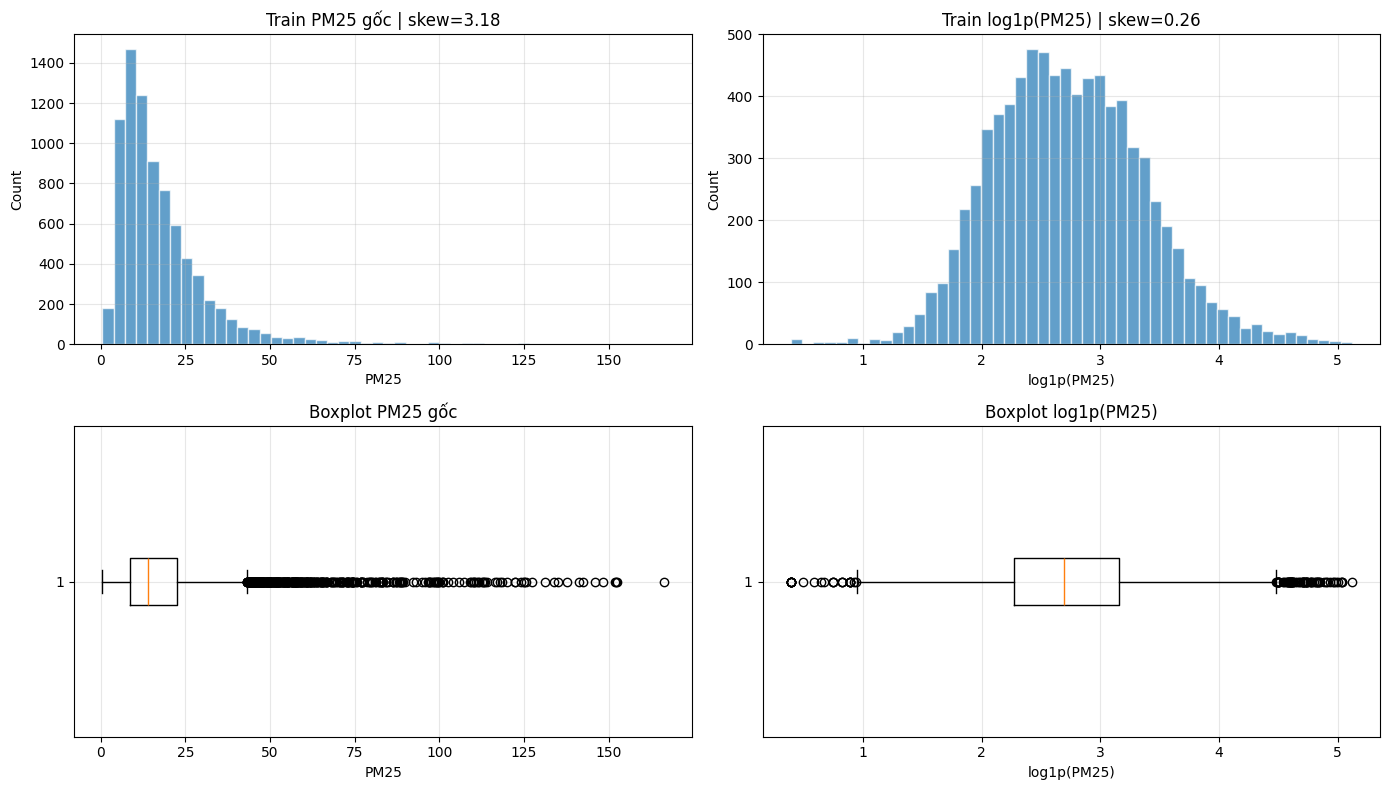

Độ lệch (skew) của dữ liệu gốc: 3.1833155215045283
Độ lệch (skew) sau log: 0.2648290972292766


In [10]:

y_train_raw_1d = y_train_raw.ravel()
y_val_raw_1d   = y_val_raw.ravel()
y_test_raw_1d  = y_test_raw.ravel()

y_train_t_1d = y_train_t.ravel()
y_val_t_1d   = y_val_t.ravel()
y_test_t_1d  = y_test_t.ravel()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1) Histogram trước log
axes[0, 0].hist(y_train_raw_1d, bins=50, alpha=0.7, edgecolor="white", label="Train")
axes[0, 0].set_title(f"Train PM25 gốc | skew={pd.Series(y_train_raw_1d).skew():.2f}")
axes[0, 0].set_xlabel("PM25")
axes[0, 0].set_ylabel("Count")
axes[0, 0].grid(alpha=0.3)

# 2) Histogram sau log1p
axes[0, 1].hist(y_train_t_1d, bins=50, alpha=0.7, edgecolor="white", label="Train")
axes[0, 1].set_title(f"Train log1p(PM25) | skew={pd.Series(y_train_t_1d).skew():.2f}")
axes[0, 1].set_xlabel("log1p(PM25)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].grid(alpha=0.3)

# 3) Boxplot trước log
axes[1, 0].boxplot(y_train_raw_1d, vert=False)
axes[1, 0].set_title("Boxplot PM25 gốc")
axes[1, 0].set_xlabel("PM25")
axes[1, 0].grid(alpha=0.3)

# 4) Boxplot sau log1p
axes[1, 1].boxplot(y_train_t_1d, vert=False)
axes[1, 1].set_title("Boxplot log1p(PM25)")
axes[1, 1].set_xlabel("log1p(PM25)")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Độ lệch (skew) của dữ liệu gốc:", pd.Series(y_train_raw_1d).skew())
print("Độ lệch (skew) sau log:", pd.Series(y_train_t_1d).skew())

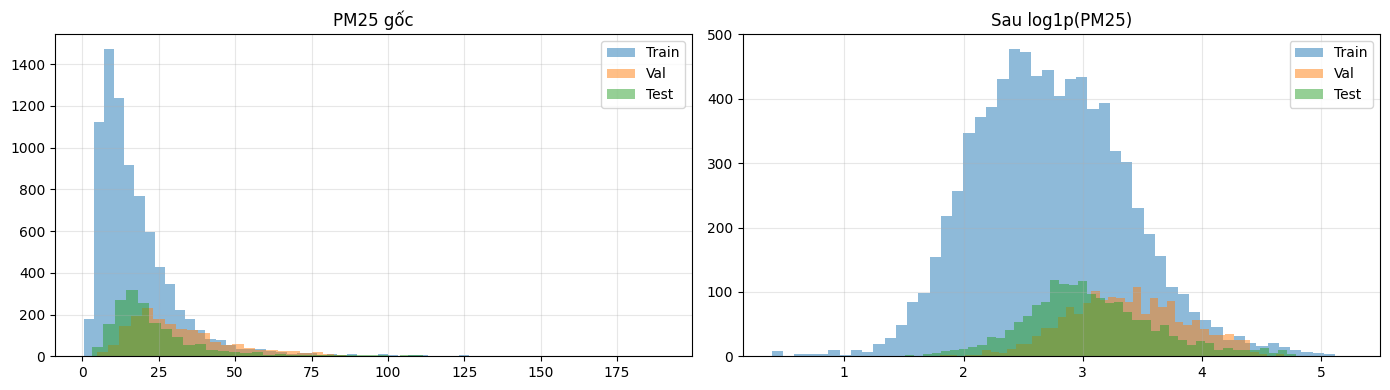

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(y_train_raw.ravel(), bins=50, alpha=0.5, label="Train")
axes[0].hist(y_val_raw.ravel(), bins=50, alpha=0.5, label="Val")
axes[0].hist(y_test_raw.ravel(), bins=50, alpha=0.5, label="Test")
axes[0].set_title("PM25 gốc")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(y_train_t.ravel(), bins=50, alpha=0.5, label="Train")
axes[1].hist(y_val_t.ravel(), bins=50, alpha=0.5, label="Val")
axes[1].hist(y_test_t.ravel(), bins=50, alpha=0.5, label="Test")
axes[1].set_title("Sau log1p(PM25)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

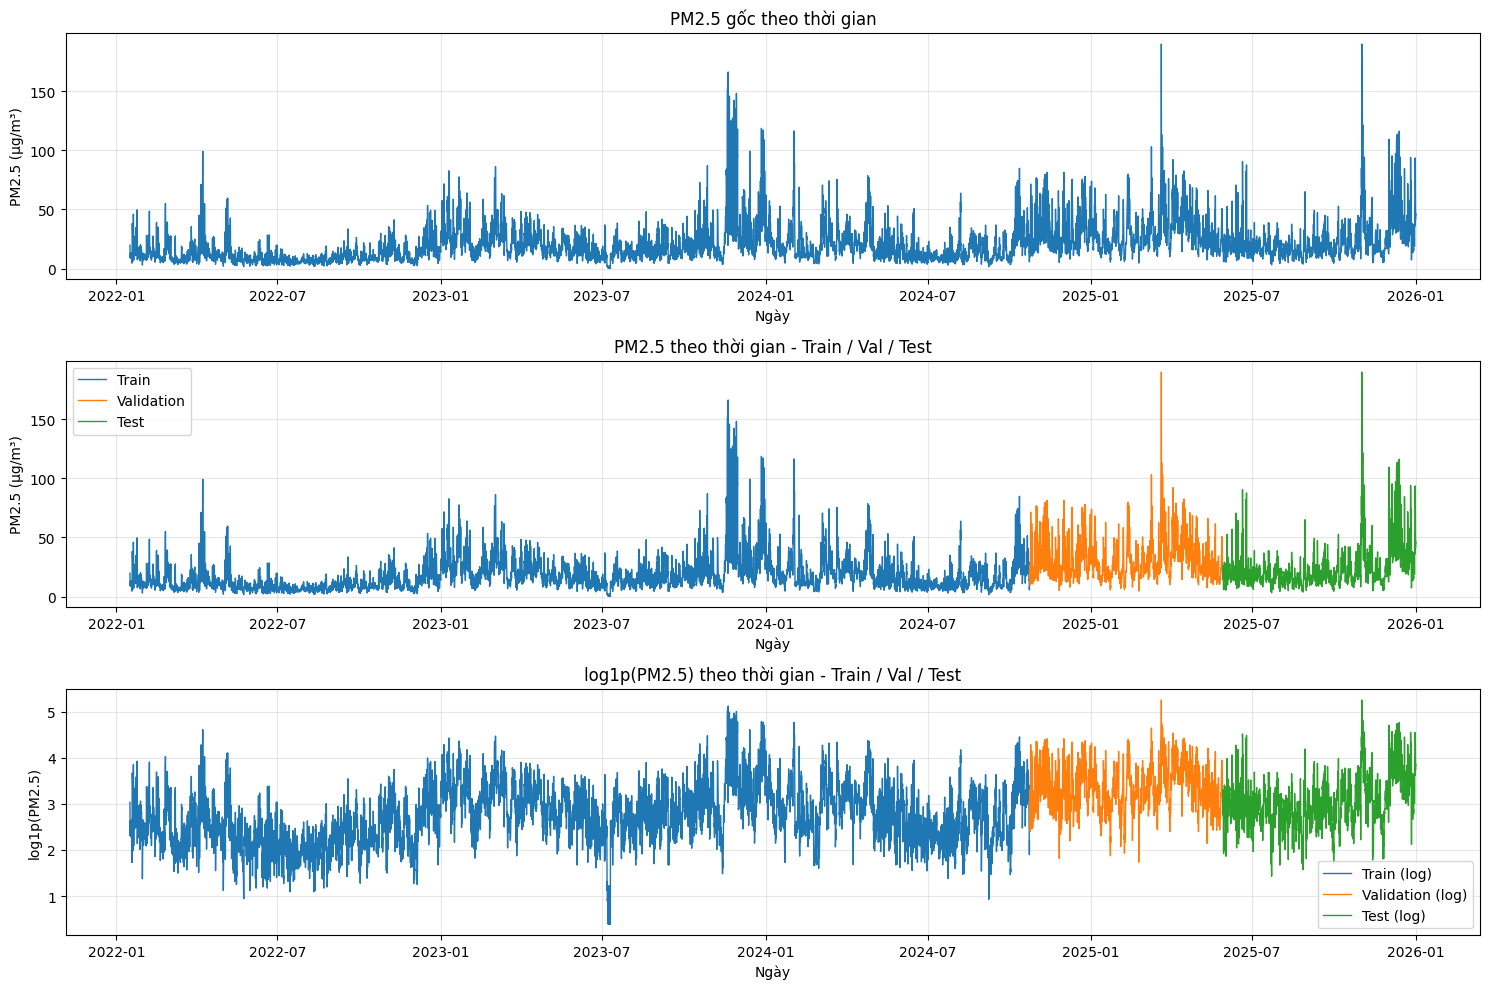

In [12]:


# ===== Tạo log PM25 =====
train_log = np.log1p(train_df["PM25"])
val_log   = np.log1p(val_df["PM25"])
test_log  = np.log1p(test_df["PM25"])

# ===== Vẽ =====
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# 1) PM2.5 gốc toàn bộ theo thời gian
axes[0].plot(df.index, df["PM25"], linewidth=1)
axes[0].set_title("PM2.5 gốc theo thời gian")
axes[0].set_ylabel("PM2.5 (µg/m³)")
axes[0].set_xlabel("Ngày")
axes[0].grid(True, alpha=0.3)

# 2) PM2.5 gốc theo split Train / Val / Test
axes[1].plot(train_df.index, train_df["PM25"], label="Train", linewidth=1)
axes[1].plot(val_df.index, val_df["PM25"], label="Validation", linewidth=1)
axes[1].plot(test_df.index, test_df["PM25"], label="Test", linewidth=1)
axes[1].set_title("PM2.5 theo thời gian - Train / Val / Test")
axes[1].set_ylabel("PM2.5 (µg/m³)")
axes[1].set_xlabel("Ngày")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3) log1p(PM2.5) theo split Train / Val / Test
axes[2].plot(train_df.index, train_log, label="Train (log)", linewidth=1)
axes[2].plot(val_df.index, val_log, label="Validation (log)", linewidth=1)
axes[2].plot(test_df.index, test_log, label="Test (log)", linewidth=1)
axes[2].set_title("log1p(PM2.5) theo thời gian - Train / Val / Test")
axes[2].set_ylabel("log1p(PM2.5)")
axes[2].set_xlabel("Ngày")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

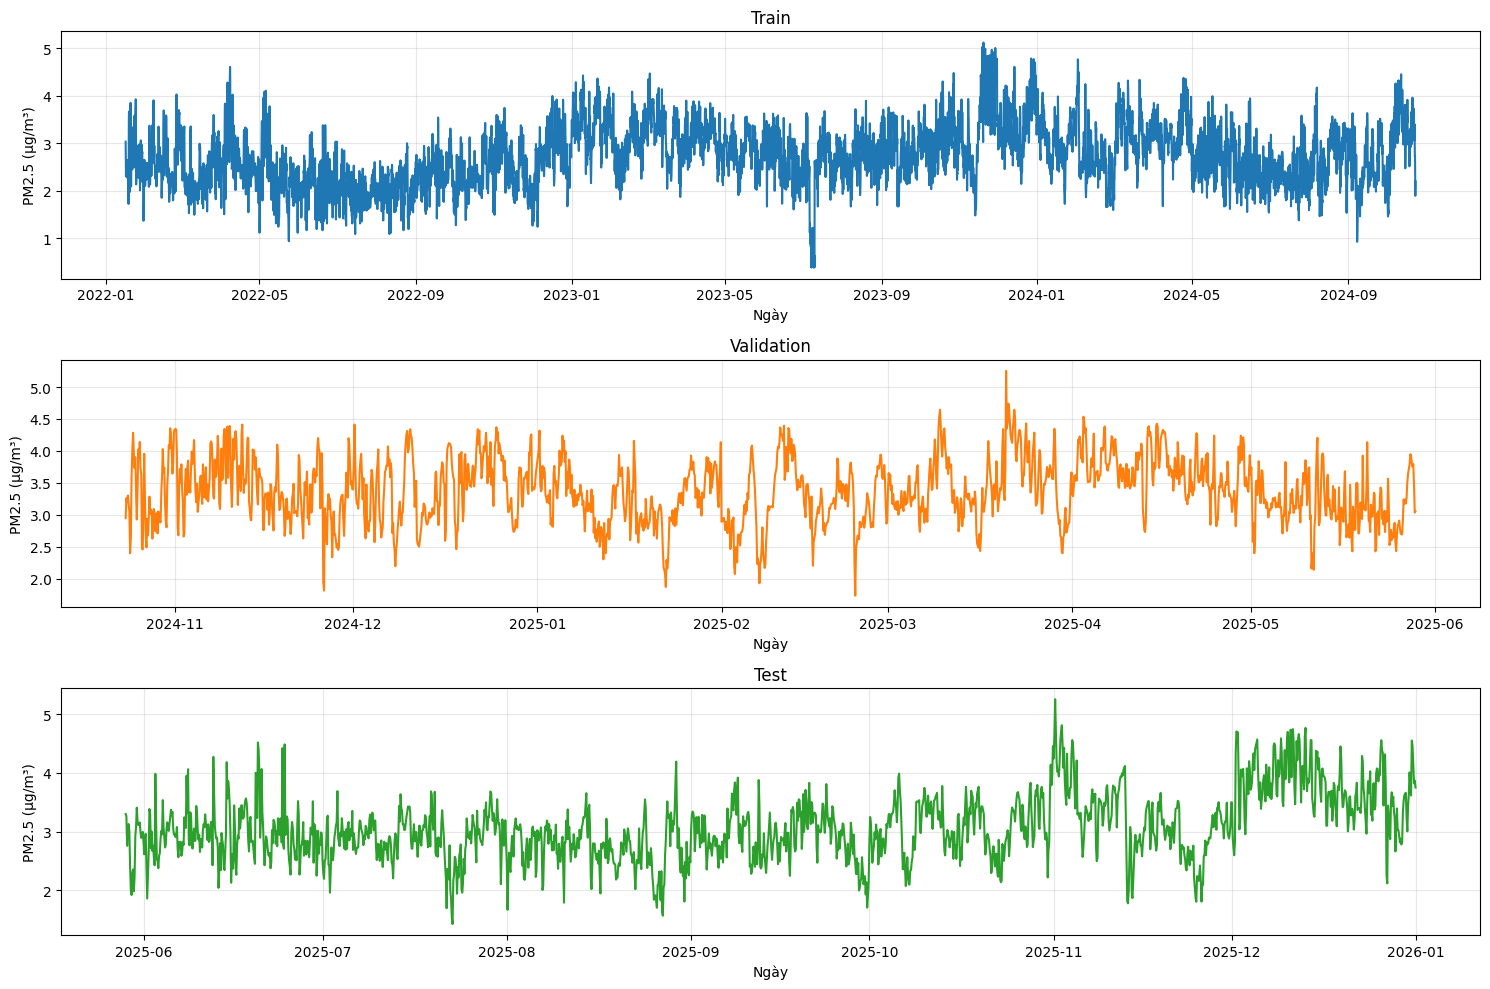

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=False)

axes[0].plot(train_df.index, train_log, label="Train")
axes[0].set_title("Train")
axes[0].grid(alpha=0.3)

axes[1].plot(val_df.index, val_log, label="Validation", color='C1')
axes[1].set_title("Validation")
axes[1].grid(alpha=0.3)

axes[2].plot(test_df.index, test_log, label="Test", color='C2')
axes[2].set_title("Test")
axes[2].grid(alpha=0.3)

for ax in axes:
    ax.set_ylabel("PM2.5 (µg/m³)")
    ax.set_xlabel("Ngày")

plt.tight_layout()
plt.show()

In [37]:
df = df.copy()

df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek
df["month"] = df.index.month

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

for lag in [1, 8, 24, 56]:
    df[f"PM25_lag_{lag}"] = df["PM25"].shift(lag)

shifted = df["PM25"].shift(1)

# df["PM25_ewm_mean_8"] = shifted.ewm(span=8, adjust=False).mean()
# df["PM25_ewm_mean_24"] = shifted.ewm(span=24, adjust=False).mean()
df["PM25_diff_1"] = shifted.diff(1)
df["PM25_diff_8"] = shifted.diff(8)

df = df.dropna().copy()

base_features = [
    "PM25_lag_1", "PM25_lag_8", "PM25_lag_24", "PM25_lag_56",
    "PM25_diff_1", "PM25_diff_8",
]

weather_features = [
    "Temperature", "Pressure", "Wind Speed",
    "Clouds", "Precipitation", "Relative Humidity",
    "Accumulated Hours of Rain",
]

pollution_features = ["PM10", "CO", "NO2", "O3", "SO2"]

calendar_features = [
    "hour_sin", "hour_cos",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",
    "IsHoliday",
]

manual_v1_features = (
    base_features
    + ["PM10", "CO", "NO2"]
    + ["Temperature", "Pressure", "Wind Speed", "Relative Humidity", "Precipitation", "Clouds"]
    + calendar_features
)

production_v1_features = base_features + calendar_features

feature_groups = {
    "base": base_features,
    "weather": weather_features,
    "pollution": pollution_features,
    "calendar": calendar_features,
}

candidate_feature_sets = {
    "base": base_features,
    "base_weather": base_features + weather_features,
    "base_weather_pollution": base_features + weather_features + pollution_features,
    "manual_v1": manual_v1_features,
    "production_v1": production_v1_features,
    "optimistic_v1": manual_v1_features,
    "all": base_features + weather_features + pollution_features + calendar_features,
}

GRA_POOL_NAME = "all"
GRA_TOP_K = 15
GRA_RHO = 0.5


def _minmax_01(values):
    values = np.asarray(values, dtype=np.float64).reshape(-1)
    vmin = np.nanmin(values)
    vmax = np.nanmax(values)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or np.isclose(vmax, vmin):
        return np.zeros_like(values, dtype=np.float64)
    return (values - vmin) / (vmax - vmin)


def compute_gra_scores(X_df, y_series, rho=0.5):
    ref = _minmax_01(np.asarray(y_series, dtype=np.float64).reshape(-1))
    diffs = []
    normalized = {}

    for col in X_df.columns:
        seq = _minmax_01(X_df[col].to_numpy(dtype=np.float64))
        normalized[col] = seq
        diffs.append(np.abs(ref - seq))

    diff_matrix = np.vstack(diffs)
    delta_min = float(np.min(diff_matrix))
    delta_max = float(np.max(diff_matrix))
    if np.isclose(delta_max, 0.0):
        delta_max = 1.0

    rows = []
    for col in X_df.columns:
        diff = np.abs(ref - normalized[col])
        coeff = (delta_min + rho * delta_max) / (diff + rho * delta_max)
        rows.append({
            "feature": col,
            "gra_score": float(np.mean(coeff)),
        })

    return pd.DataFrame(rows).sort_values(["gra_score", "feature"], ascending=[False, True]).reset_index(drop=True)


for name, cols in candidate_feature_sets.items():
    missing_cols = [col for col in cols if col not in df.columns]
    if missing_cols:
        print(f"{name}: thiếu cột -> {missing_cols}")
    else:
        print(f"{name}: {len(cols)} đặc trưng")

feature_cols = candidate_feature_sets["all"]
print("Bộ đặc trưng production mặc định:", feature_cols)


base: 6 đặc trưng
base_weather: 13 đặc trưng
base_weather_pollution: 18 đặc trưng
manual_v1: 22 đặc trưng
production_v1: 13 đặc trưng
optimistic_v1: 22 đặc trưng
all: 25 đặc trưng
Bộ đặc trưng production mặc định: ['PM25_lag_1', 'PM25_lag_8', 'PM25_lag_24', 'PM25_lag_56', 'PM25_diff_1', 'PM25_diff_8', 'Temperature', 'Pressure', 'Wind Speed', 'Clouds', 'Precipitation', 'Relative Humidity', 'Accumulated Hours of Rain', 'PM10', 'CO', 'NO2', 'O3', 'SO2', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'IsHoliday']


In [39]:
# ===== Quick benchmark config for 3H aggregated data =====
LOOKBACK = 56                 # 56 x 3H = 168H = 7 ngay lich su
CHUNK_HORIZON = 4             # 4 x 3H = 12H moi chunk
ROLLOUT_HORIZON = 24          # 24 x 3H = 72H rollout
N_CHUNKS = ROLLOUT_HORIZON // CHUNK_HORIZON
HORIZON = CHUNK_HORIZON
EVAL_SIZE = ROLLOUT_HORIZON
STEP_SIZE = ROLLOUT_HORIZON
STEP_HOURS = 3
MAX_FOLDS = 1                 # giảm folds để nhanh
EPOCHS = 50                   # ít epoch để vòng loại nhanh
BATCH_SIZE = 32
SEED = 42
TARGET_TRANSFORM_MODE = "log1p"   # thử log1p (thường ổn định hơn sqrt)
SELECTED_FEATURE_SET = "all"
OPTIMISTIC_FEATURE_SET = "optimistic_v1"
INNER_VAL_SIZE = 56           # 56 x 3H = 7 ngay inner validation
PEAK_QUANTILE = 0.90
PEAK_WEIGHT = 3.0      # giảm trọng số peak lúc benchmark
HUBER_DELTA = 1.0
ROLLING_POLICY = "assimilated"
FEATURE_SET_COMPARE = [SELECTED_FEATURE_SET, OPTIMISTIC_FEATURE_SET]

np.random.seed(SEED)
tf.random.set_seed(SEED)

production_feature_cols = candidate_feature_sets[SELECTED_FEATURE_SET]
optimistic_feature_cols = candidate_feature_sets[OPTIMISTIC_FEATURE_SET]
feature_cols = production_feature_cols

print("Bộ đặc trưng production đang dùng:", SELECTED_FEATURE_SET)
print("Số lượng đặc trưng production:", len(production_feature_cols))
print("LOOKBACK / CHUNK_HORIZON / ROLLOUT_HORIZON:", LOOKBACK, CHUNK_HORIZON, ROLLOUT_HORIZON)
print("MAX_FOLDS, EPOCHS:", MAX_FOLDS, EPOCHS)
print("INNER_VAL_SIZE:", INNER_VAL_SIZE)
print("TARGET_TRANSFORM_MODE:", TARGET_TRANSFORM_MODE)


Bộ đặc trưng production đang dùng: all
Số lượng đặc trưng production: 25
LOOKBACK / CHUNK_HORIZON / ROLLOUT_HORIZON: 56 4 24
MAX_FOLDS, EPOCHS: 1 50
INNER_VAL_SIZE: 56
TARGET_TRANSFORM_MODE: log1p


In [40]:
# ===== Sequence building + Seq2Seq GRU / Attention model =====
def make_sequences(X, y, lookback=72, horizon=72):
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32).reshape(-1)

    X_seq, decoder_seq, y_seq = [], [], []
    max_start = len(X) - lookback - horizon + 1
    if max_start <= 0:
        return (
            np.empty((0, lookback, X.shape[1]), dtype=np.float32),
            np.empty((0, horizon, 1), dtype=np.float32),
            np.empty((0, horizon), dtype=np.float32),
        )

    for i in range(max_start):
        X_seq.append(X[i:i + lookback])
        y_future = y[i + lookback:i + lookback + horizon]
        decoder_seed = np.concatenate([[y[i + lookback - 1]], y_future[:-1]]).astype(np.float32)
        decoder_seq.append(decoder_seed.reshape(-1, 1))
        y_seq.append(y_future)

    return (
        np.asarray(X_seq, dtype=np.float32),
        np.asarray(decoder_seq, dtype=np.float32),
        np.asarray(y_seq, dtype=np.float32),
    )


def build_gru_model(
    lookback,
    n_features,
    horizon,
    gru_units=(128, 64),
    dense_units=128,
    dropout=0.2,
    recurrent_dropout=0.0,
    learning_rate=5e-4,
    loss_fn="mse",
    l2_reg=0.0,
    clipnorm=1.0,
    use_attention=False,
):
    if isinstance(gru_units, int):
        gru_units = (gru_units, max(gru_units // 2, 32))
    elif len(gru_units) == 1:
        gru_units = (gru_units[0], max(gru_units[0] // 2, 32))

    encoder_units = gru_units[0]
    decoder_units = tuple(gru_units[1:]) if len(gru_units) > 1 else (max(encoder_units // 2, 32),)
    decoder_last_units = decoder_units[-1]
    decoder_first_units = decoder_units[0]
    regularizer = tf.keras.regularizers.l2(l2_reg) if l2_reg and l2_reg > 0 else None

    encoder_inputs = tf.keras.layers.Input(shape=(lookback, n_features), name="encoder_inputs")
    decoder_inputs = tf.keras.layers.Input(shape=(horizon, 1), name="decoder_inputs")

    # Use return_state to get encoder state directly (more robust than slicing last output)
    encoder_outputs, encoder_state = tf.keras.layers.GRU(
        encoder_units,
        return_sequences=True,
        return_state=True,
        dropout=dropout,
        recurrent_dropout=recurrent_dropout,
        kernel_regularizer=regularizer,
        name="encoder_gru",
    )(encoder_inputs)

    if encoder_units != decoder_first_units:
        decoder_initial_state = tf.keras.layers.Dense(
            decoder_first_units,
            activation="tanh",
            kernel_regularizer=regularizer,
            name="decoder_init_projection",
        )(encoder_state)
    else:
        decoder_initial_state = encoder_state

    x = decoder_inputs

    for i, units in enumerate(decoder_units, start=1):
        x = tf.keras.layers.GRU(
            units,
            return_sequences=True,
            dropout=dropout,
            recurrent_dropout=recurrent_dropout,
            kernel_regularizer=regularizer,
            name=f"decoder_gru_{i}",
        )(
            x,
            initial_state=[decoder_initial_state] if i == 1 else None,
        )

    decoder_outputs = x

    if use_attention:
        attention_values = encoder_outputs
        if encoder_units != decoder_last_units:
            attention_values = tf.keras.layers.Dense(
                decoder_last_units,
                kernel_regularizer=regularizer,
                name="encoder_attention_projection",
            )(attention_values)

        attention_context = tf.keras.layers.AdditiveAttention(name="temporal_attention")(
            [decoder_outputs, attention_values]
        )
        x = tf.keras.layers.Concatenate(name="decoder_attention_concat")(
            [decoder_outputs, attention_context]
        )
    else:
        x = decoder_outputs

    if dense_units:
        x = tf.keras.layers.TimeDistributed(
            tf.keras.layers.Dense(
                dense_units,
                activation="relu",
                kernel_initializer="he_normal",
                kernel_regularizer=regularizer,
            ),
            name="time_distributed_dense",
        )(x)
        x = tf.keras.layers.Dropout(dropout, name="decoder_dropout")(x)

    x = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(1),
        name="time_distributed_output",
    )(x)

    outputs = tf.keras.layers.Reshape((horizon,), name="forecast_output")(x)

    model_name = "seq2seq_gru_attention" if use_attention else "seq2seq_gru"
    model = tf.keras.Model(inputs=[encoder_inputs, decoder_inputs], outputs=outputs, name=model_name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=clipnorm),
        loss=loss_fn,
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")],
    )
    return model


def make_weighted_huber_loss(peak_threshold, peak_weight=2.0, delta=1.0, horizon=72):
    """
    Weighted Huber that:
      - gives extra weight to steps above peak_threshold
      - applies step weights (increasing across horizon) but normalized to mean=1
    """
    peak_threshold = tf.constant(float(peak_threshold), dtype=tf.float32)
    peak_weight = tf.constant(float(peak_weight), dtype=tf.float32)
    delta = tf.constant(float(delta), dtype=tf.float32)
    # step weights: increasing across horizon, normalized to mean 1.0
    raw_step_weights = tf.reshape(tf.linspace(1.0, 1.8, horizon), (1, horizon))
    step_weights = raw_step_weights / tf.reduce_mean(raw_step_weights)

    def loss(y_true, y_pred):
        # y_true/y_pred shapes: (batch, horizon)
        error = y_true - y_pred
        abs_error = tf.abs(error)
        huber = tf.where(
            abs_error <= delta,
            0.5 * tf.square(error),
            delta * (abs_error - 0.5 * delta),
        )
        peak_mask = tf.cast(y_true >= peak_threshold, tf.float32)  # 1 where peak
        peak_weights = 1.0 + peak_weight * peak_mask   # shape (batch, horizon)
        weighted = huber * peak_weights * step_weights  # broadcast step_weights (1,h)
        # mean over horizon then mean over batch
        return tf.reduce_mean(weighted)

    return loss


In [41]:
# ===== Metrics + aggregation =====

# tính toán các metric MAE, RMSE, MAPE tổng thể và riêng cho các điểm đỉnh (peak) dựa trên ngưỡng quantile.
def compute_regression_metrics(y_true_flat, y_pred_flat, peak_quantile=0.90):
    y_true_flat = np.asarray(y_true_flat, dtype=np.float64).reshape(-1)
    y_pred_flat = np.asarray(y_pred_flat, dtype=np.float64).reshape(-1)

    metrics = {
        "mae": mean_absolute_error(y_true_flat, y_pred_flat),
        "rmse": np.sqrt(mean_squared_error(y_true_flat, y_pred_flat)),
        "mape": np.mean(
            np.abs((y_true_flat - y_pred_flat) / np.clip(np.abs(y_true_flat), 1e-6, None))
        ) * 100,
    }

    peak_threshold = float(np.quantile(y_true_flat, peak_quantile))
    peak_mask = y_true_flat >= peak_threshold
    metrics["peak_threshold"] = peak_threshold
    metrics["peak_mae"] = mean_absolute_error(y_true_flat[peak_mask], y_pred_flat[peak_mask]) if np.any(peak_mask) else np.nan
    return metrics


def aggregate_multistep_forecasts(eval_index, y_true_2d, y_pred_2d):
    rows = []
    y_true_2d = np.asarray(y_true_2d, dtype=np.float64)
    y_pred_2d = np.asarray(y_pred_2d, dtype=np.float64)

    for seq_idx in range(y_pred_2d.shape[0]):
        for h in range(y_pred_2d.shape[1]):
            rows.append({
                "timestamp": eval_index[seq_idx + h],
                "horizon_step": h + 1,
                "y_true": y_true_2d[seq_idx, h],
                "y_pred": y_pred_2d[seq_idx, h],
            })

    long_df = pd.DataFrame(rows)
    agg_df = (
        long_df.groupby("timestamp", as_index=False)
        .agg(
            y_true=("y_true", "mean"),
            y_pred=("y_pred", "mean"),
            pred_std=("y_pred", "std"),
            n_votes=("y_pred", "size"),
        )
        .sort_values("timestamp")
    )
    agg_df["pred_std"] = agg_df["pred_std"].fillna(0.0)
    return long_df, agg_df


# Tính metric riêng cho từng horizon step.
def compute_horizon_step_metrics(long_df, peak_quantile=0.90):
    rows = []
    for horizon_step, step_df in long_df.groupby("horizon_step", sort=True):
        metrics = compute_regression_metrics(
            step_df["y_true"].to_numpy(),
            step_df["y_pred"].to_numpy(),
            peak_quantile=peak_quantile,
        )
        rows.append({
            "horizon_step": int(horizon_step),
            "n_points": int(len(step_df)),
            "mae": metrics["mae"],
            "rmse": metrics["rmse"],
            "mape": metrics["mape"],
            "peak_mae": metrics["peak_mae"],
            "peak_threshold": metrics["peak_threshold"],
        })
    return pd.DataFrame(rows)


# Gom toàn bộ quy trình đánh giá multi-step forecasting: từ long format, aggregate theo timestamp, tính metric theo horizon step, và metric tổng thể.
def summarize_multistep_predictions(eval_index, y_true_2d, y_pred_2d, peak_quantile=0.90):
    long_df, agg_df = aggregate_multistep_forecasts(eval_index, y_true_2d, y_pred_2d)
    horizon_metrics_df = compute_horizon_step_metrics(long_df, peak_quantile=peak_quantile)
    step1_df = long_df[long_df["horizon_step"] == 1].sort_values("timestamp").reset_index(drop=True)

    raw_metrics = compute_regression_metrics(
        np.asarray(y_true_2d, dtype=np.float64).reshape(-1),
        np.asarray(y_pred_2d, dtype=np.float64).reshape(-1),
        peak_quantile=peak_quantile,
    )
    step1_metrics = compute_regression_metrics(
        step1_df["y_true"].to_numpy(),
        step1_df["y_pred"].to_numpy(),
        peak_quantile=peak_quantile,
    )
    agg_metrics = compute_regression_metrics(
        agg_df["y_true"].to_numpy(),
        agg_df["y_pred"].to_numpy(),
        peak_quantile=peak_quantile,
    )

    return {
        "long_df": long_df,
        "agg_df": agg_df,
        "step1_df": step1_df,
        "horizon_metrics_df": horizon_metrics_df,
        "raw_metrics": raw_metrics,
        "step1_metrics": step1_metrics,
        "agg_metrics": agg_metrics,
    }


In [42]:
from sklearn.preprocessing import StandardScaler
import numpy as np

def transform_target(y_raw, scaler=None, fit=False, mode="log1p"):
    """
    Biến đổi

    - y_raw: mảng 1D của giá trị PM2.5 gốc (có thể chứa âm, sẽ được xử lý)
    - scaler: instance của StandardScaler đã fit trên dữ liệu train (nếu fit=False) hoặc None (nếu fit=True)
    - fit: nếu True, sẽ fit scaler trên dữ liệu y_raw đã biến đổi; nếu False, sẽ sử dụng scaler đã cung cấp để transform
    - mode: kiểu biến đổi mục tiêu, có thể là "log1p", "sqrt", hoặc "raw" (chỉ clip âm và scale)
    """
    y_raw = np.asarray(y_raw, dtype=np.float64).reshape(-1)
    # clip negatives to zero to ensure no negative PM2.5
    y_clip = np.clip(y_raw, 0.0, None)

    if mode == "log1p":
        y_t = np.log1p(y_clip).reshape(-1, 1)
    elif mode == "sqrt":
        y_t = np.sqrt(y_clip).reshape(-1, 1)
    elif mode == "raw":
        # use clipped (non-negative) values for raw mode as well
        y_t = y_clip.reshape(-1, 1)
    else:
        raise ValueError(f"Chế độ biến đổi không hợp lệ: {mode}")

    if fit:
        scaler = StandardScaler()
        scaler.fit(y_t)
    elif scaler is None:
        raise ValueError("Khi fit=False, scaler không được để trống")

    y_scaled = scaler.transform(y_t).reshape(-1)
    return y_scaled, scaler


def inverse_target(y_scaled, scaler, mode="log1p"):
    y_scaled = np.asarray(y_scaled, dtype=np.float64)
    original_shape = y_scaled.shape
    # inverse scaler
    y_unscaled = scaler.inverse_transform(y_scaled.reshape(-1, 1)).reshape(-1)

    if mode == "log1p":
        # expm1 is numerically stable for small inputs
        y_raw = np.expm1(y_unscaled)
    elif mode == "sqrt":
        # ensure non-negative before squaring (numerical safety)
        y_raw = np.square(np.clip(y_unscaled, 0.0, None))
    elif mode == "raw":
        y_raw = y_unscaled  # already on original scale (but we will clip negatives below)
    else:
        raise ValueError(f"Chế độ biến đổi không hợp lệ: {mode}")

    y_raw = np.clip(y_raw, 0.0, None)
    # reshape back to original input shape
    return y_raw.reshape(original_shape)

In [43]:
# ===== Data prep for train/eval =====

PRODUCTION_LAGS = [1, 8, 24, 56]



def build_history_feature_frame(raw_df):
    raw_df = raw_df.copy().sort_index()

    raw_df["hour"] = raw_df.index.hour
    raw_df["dayofweek"] = raw_df.index.dayofweek
    raw_df["month"] = raw_df.index.month
    raw_df["hour_sin"] = np.sin(2 * np.pi * raw_df["hour"] / 24)
    raw_df["hour_cos"] = np.cos(2 * np.pi * raw_df["hour"] / 24)
    raw_df["dow_sin"] = np.sin(2 * np.pi * raw_df["dayofweek"] / 7)
    raw_df["dow_cos"] = np.cos(2 * np.pi * raw_df["dayofweek"] / 7)
    raw_df["month_sin"] = np.sin(2 * np.pi * raw_df["month"] / 12)
    raw_df["month_cos"] = np.cos(2 * np.pi * raw_df["month"] / 12)

    for lag in PRODUCTION_LAGS:
        raw_df[f"PM25_lag_{lag}"] = raw_df["PM25"].shift(lag)

    shifted = raw_df["PM25"].shift(1)

    raw_df["PM25_diff_1"] = shifted.diff(1)
    raw_df["PM25_diff_8"] = shifted.diff(8)
    return raw_df



def prepare_train_eval_sequences(train_X_df, train_y_df, eval_X_df, eval_y_df, lookback=72, horizon=72, target_mode="log1p"):
    if len(train_X_df) <= lookback:
        raise ValueError("train_X_df ph?i có ít nh?t `lookback` hàng")

    x_scaler = StandardScaler()
    X_train_scaled = x_scaler.fit_transform(train_X_df.values)
    X_eval_scaled = x_scaler.transform(eval_X_df.values)

    y_train_scaled, y_scaler = transform_target(
        train_y_df.values.reshape(-1), scaler=None, fit=True, mode=target_mode
    )
    y_eval_scaled, _ = transform_target(
        eval_y_df.values.reshape(-1), scaler=y_scaler, fit=False, mode=target_mode
    )

    X_train_seq, decoder_train_seq, y_train_seq = make_sequences(
        X_train_scaled, y_train_scaled, lookback=lookback, horizon=horizon
    )

    X_context = np.vstack([X_train_scaled[-lookback:], X_eval_scaled])
    y_context = np.concatenate([y_train_scaled[-lookback:], y_eval_scaled])
    X_eval_seq, decoder_eval_seq, y_eval_seq = make_sequences(
        X_context, y_context, lookback=lookback, horizon=horizon
    )

    return (
        X_train_seq,
        decoder_train_seq,
        y_train_seq,
        X_eval_seq,
        decoder_eval_seq,
        y_eval_seq,
        x_scaler,
        y_scaler,
    )


def build_inference_inputs(history_raw_df, feature_cols, x_scaler, y_scaler, lookback=72, target_mode="log1p"):
    feature_frame = build_history_feature_frame(history_raw_df)
    feature_frame = feature_frame.dropna(subset=feature_cols + ["PM25"]).copy()
    if len(feature_frame) < lookback:
        raise ValueError("Không d? lịch sử sau khi tạo feature d? d?ng input inference.")

    X_window = feature_frame[feature_cols].tail(lookback).to_numpy(dtype=np.float32)
    X_scaled = x_scaler.transform(X_window)
    last_target_scaled, _ = transform_target(
        np.array([feature_frame["PM25"].iloc[-1]], dtype=np.float32),
        scaler=y_scaler,
        fit=False,
        mode=target_mode,
    )
    return X_scaled[np.newaxis, ...], float(last_target_scaled[0])


def summarize_rollout_predictions(rollout_df, peak_quantile=0.90):
    rollout_df = rollout_df.copy().sort_values("timestamp").reset_index(drop=True)
    rollout_df["pred_std"] = 0.0

    chunk_rows = []
    for chunk_id, chunk_df in rollout_df.groupby("chunk_id", sort=True):
        metrics = compute_regression_metrics(
            chunk_df["y_true"].to_numpy(),
            chunk_df["y_pred"].to_numpy(),
            peak_quantile=peak_quantile,
        )
        chunk_rows.append({
            "chunk_id": int(chunk_id),
            "n_points": int(len(chunk_df)),
            "mae": metrics["mae"],
            "rmse": metrics["rmse"],
            "mape": metrics["mape"],
            "peak_mae": metrics["peak_mae"],
            "peak_threshold": metrics["peak_threshold"],
        })

    chunk_metrics_df = pd.DataFrame(chunk_rows)
    rollout_metrics = compute_regression_metrics(
        rollout_df["y_true"].to_numpy(),
        rollout_df["y_pred"].to_numpy(),
        peak_quantile=peak_quantile,
    )
    return {
        "timeline_df": rollout_df,
        "chunk_metrics_df": chunk_metrics_df,
        "rollout_metrics": rollout_metrics,
    }


def run_assimilated_rollout(
    model,
    history_raw_df,
    future_raw_df,
    feature_cols,
    x_scaler,
    y_scaler,
    lookback=72,
    chunk_horizon=24,
    rollout_horizon=72,
    target_mode="log1p",
):
    history_raw_df = history_raw_df.copy().sort_index()
    future_raw_df = future_raw_df.copy().sort_index().iloc[:rollout_horizon]
    if len(future_raw_df) < rollout_horizon:
        raise ValueError("Không đủ dữ liệu tương lai để rollout theo yêu cầu.")

    rows = []
    for chunk_start in range(0, rollout_horizon, chunk_horizon):
        chunk_id = chunk_start // chunk_horizon + 1
        chunk_future = future_raw_df.iloc[chunk_start:chunk_start + chunk_horizon].copy()
        if len(chunk_future) < chunk_horizon:
            raise ValueError("Chunk cuối không đủ dữ liệu để tạo horizon theo yêu cầu.")

        X_input, last_target_scaled = build_inference_inputs(
            history_raw_df=history_raw_df,
            feature_cols=feature_cols,
            x_scaler=x_scaler,
            y_scaler=y_scaler,
            lookback=lookback,
            target_mode=target_mode,
        )
        decoder_input = np.zeros((1, chunk_horizon, 1), dtype=np.float32)
        decoder_input[0, 0, 0] = last_target_scaled
        y_pred_scaled = np.zeros((chunk_horizon,), dtype=np.float32)

        for step_idx in range(chunk_horizon):
            decoder_forecast = model.predict([X_input, decoder_input], verbose=0)[0]
            y_pred_scaled[step_idx] = decoder_forecast[step_idx]
            if step_idx + 1 < chunk_horizon:
                decoder_input[0, step_idx + 1, 0] = y_pred_scaled[step_idx]

        y_pred = inverse_target(y_pred_scaled, y_scaler, mode=target_mode)

        for step_idx, (timestamp, y_true_value, y_pred_value) in enumerate(
            zip(chunk_future.index, chunk_future["PM25"].to_numpy(dtype=np.float64), y_pred),
            start=1,
        ):
            rows.append({
                "chunk_id": chunk_id,
                "chunk_step": step_idx,
                "global_step": chunk_start + step_idx,
                "timestamp": timestamp,
                "y_true": float(y_true_value),
                "y_pred": float(y_pred_value),
            })

        history_raw_df = pd.concat([history_raw_df, chunk_future], axis=0)

    rollout_df = pd.DataFrame(rows)
    if len(rollout_df) != rollout_horizon:
        raise ValueError("Rollout không đúng số bước yêu cầu.")

    return summarize_rollout_predictions(rollout_df, peak_quantile=PEAK_QUANTILE)



Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 21: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.
=== Walk-forward validation: production rollout 24 steps = 4 x 6 ===


,fold,train_rows,inner_val_rows,rollout_rows,rollout_mae,rollout_rmse,rollout_mape,rollout_peak_mae,rollout_peak_threshold,train_peak_threshold_t,...,chunk_4_mape,chunk_4_peak_mae,chunk_5_mae,chunk_5_rmse,chunk_5_mape,chunk_5_peak_mae,chunk_6_mae,chunk_6_rmse,chunk_6_mape,chunk_6_peak_mae
0,1,7812,56,24,12.547885,16.244282,42.654218,29.854428,54.667333,1.263031,...,25.578371,14.826724,13.856522,16.712944,24.68727,24.102428,9.795871,10.123728,64.745292,5.56768



=== Validation summary ===


,mean_rollout_mae,mean_rollout_rmse,mean_chunk_1_mae,mean_chunk_2_mae,mean_chunk_3_mae
0,12.547885,16.244282,10.426365,4.918419,29.143236



Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0003499999875202775.

Epoch 17: ReduceLROnPlateau reducing learning rate to 0.00017499999376013875.

Epoch 23: ReduceLROnPlateau reducing learning rate to 8.749999688006938e-05.

=== Hold-out test rollout metrics ===


,best_epoch,test_rollout_mae,test_rollout_rmse,test_rollout_mape,test_rollout_peak_mae,train_peak_threshold_t,train_val_peak_threshold_t
0,5,5.805939,7.173241,46.921186,6.261039,1.287889,1.28973



=== Chunk-level test metrics ===


,chunk_id,n_points,mae,rmse,mape,peak_mae,peak_threshold
0,1,4,8.449394,10.208232,47.919348,1.136847,25.811333
1,2,4,6.635925,8.594012,82.137211,0.624712,21.049333
2,3,4,5.775602,6.279172,81.607902,5.176066,9.353333
3,4,4,5.973393,7.133552,28.318674,12.196120,26.616667
4,5,4,2.767368,3.480986,12.453648,1.315106,22.929333
5,6,4,5.233950,5.313608,29.090334,4.245045,18.950000



=== Presentation table ===


,model,rollout_horizon,chunk_horizon,mae,rmse,MAPE,best_epoch
0,Seq2Seq GRU + Attention,24,4,5.805939,7.173241,46.921186,5


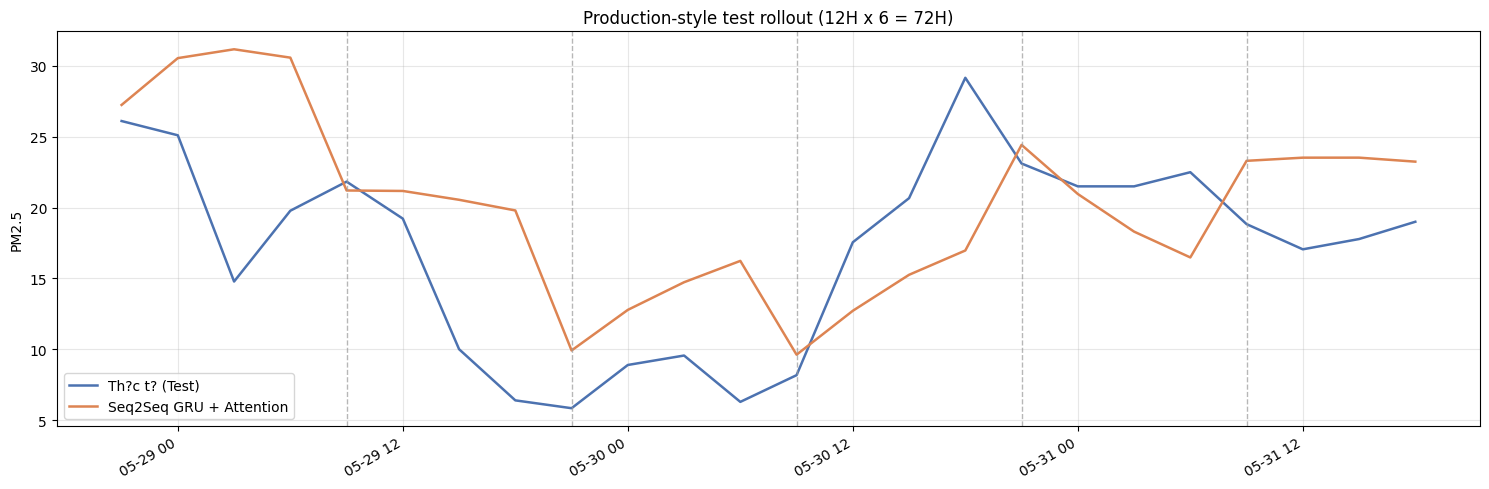

In [44]:
# ===== Walk-forward validate tren tap val, giu test hold-out =====

df_raw_rollout = df.copy().sort_index()
df_wf = build_history_feature_frame(df_raw_rollout).dropna().copy()

train_wf = df_wf[:train_end].copy()
val_wf = df_wf[val_start:val_end].copy()
test_wf = df_wf[test_start:].copy()

train_raw = df_raw_rollout[:train_end].copy()
val_raw = df_raw_rollout[val_start:val_end].copy()
test_raw = df_raw_rollout[test_start:].copy()

for feature_set_name in [SELECTED_FEATURE_SET, OPTIMISTIC_FEATURE_SET]:
    local_cols = candidate_feature_sets[feature_set_name]
    missing_feature_cols = [c for c in local_cols if c not in df_wf.columns]
    if missing_feature_cols:
        raise ValueError(f"Thiếu các cột feature cho {feature_set_name}: {missing_feature_cols}")

MODEL_KWARGS = {
    "gru_units": (128, 64),
    "dense_units": 128,
    "dropout": 0.15,
    "recurrent_dropout": 0.0,
    "learning_rate": 7e-4,
    "l2_reg": 1e-5,
    "clipnorm": 1.0,
    "use_attention": True,
}
MODEL_LABEL = "Seq2Seq GRU + Attention" if MODEL_KWARGS.get("use_attention", False) else "Seq2Seq GRU"

def make_callbacks():
    return [
        EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True, min_delta=1e-3),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-6, verbose=1),
    ]


def split_train_inner_val(train_X_df, train_y_df, inner_val_size):
    min_train_rows = LOOKBACK + CHUNK_HORIZON
    if len(train_X_df) <= inner_val_size + min_train_rows:
        raise ValueError(
            f"Không d? d? li?u d? tách inner val. C?n > {inner_val_size + min_train_rows} rows, nh?n {len(train_X_df)}"
        )
    train_core_X = train_X_df.iloc[:-inner_val_size].copy()
    train_core_y = train_y_df.iloc[:-inner_val_size].copy()
    inner_val_X = train_X_df.iloc[-inner_val_size:].copy()
    inner_val_y = train_y_df.iloc[-inner_val_size:].copy()
    return train_core_X, train_core_y, inner_val_X, inner_val_y


def fit_selector_model(train_core_X, train_core_y, inner_val_X, inner_val_y, model_kwargs=None, epochs=EPOCHS):
    model_kwargs = MODEL_KWARGS if model_kwargs is None else model_kwargs
    (
        X_train_seq,
        decoder_train_seq,
        y_train_seq,
        X_inner_val_seq,
        decoder_inner_val_seq,
        y_inner_val_seq,
        x_scaler,
        y_scaler,
    ) = prepare_train_eval_sequences(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        lookback=LOOKBACK,
        horizon=CHUNK_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )

    if len(X_train_seq) == 0 or len(X_inner_val_seq) == 0:
        raise ValueError("Không tạo được sequence cho train ho?c inner val. Ki?m tra l?i kích thu?c d? li?u và lookback/horizon.")

    peak_threshold = float(np.quantile(y_train_seq.reshape(-1), PEAK_QUANTILE))
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=PEAK_WEIGHT,
        delta=HUBER_DELTA,
        horizon=CHUNK_HORIZON,
    )

    model = build_gru_model(
        lookback=LOOKBACK,
        n_features=X_train_seq.shape[2],
        horizon=CHUNK_HORIZON,
        loss_fn=loss_fn,
        **model_kwargs,
    )
    history = model.fit(
        [X_train_seq, decoder_train_seq],
        y_train_seq,
        validation_data=([X_inner_val_seq, decoder_inner_val_seq], y_inner_val_seq),
        epochs=epochs,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks(),
        verbose=0,
    )
    best_epoch = int(np.argmin(history.history["val_loss"])) + 1
    return model, history, best_epoch, x_scaler, y_scaler, peak_threshold


def fit_full_history_model(full_X_df, full_y_df, epochs, model_kwargs=None):
    model_kwargs = MODEL_KWARGS if model_kwargs is None else model_kwargs
    x_scaler = StandardScaler()
    X_full_scaled = x_scaler.fit_transform(full_X_df.values)
    y_full_scaled, y_scaler = transform_target(
        full_y_df.values.reshape(-1), scaler=None, fit=True, mode=TARGET_TRANSFORM_MODE
    )
    X_full_seq, decoder_full_seq, y_full_seq = make_sequences(
        X_full_scaled, y_full_scaled, lookback=LOOKBACK, horizon=CHUNK_HORIZON
    )

    if len(X_full_seq) == 0:
        raise ValueError("Không t?o du?c sequence full-history")

    peak_threshold = float(np.quantile(y_full_seq.reshape(-1), PEAK_QUANTILE))
    loss_fn = make_weighted_huber_loss(
        peak_threshold=peak_threshold,
        peak_weight=PEAK_WEIGHT,
        delta=HUBER_DELTA,
        horizon=CHUNK_HORIZON,
    )

    model = build_gru_model(
        lookback=LOOKBACK,
        n_features=X_full_seq.shape[2],
        horizon=CHUNK_HORIZON,
        loss_fn=loss_fn,
        **model_kwargs,
    )
    model.fit(
        [X_full_seq, decoder_full_seq],
        y_full_seq,
        epochs=epochs,
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    return model, x_scaler, y_scaler, peak_threshold


def fit_test_variant(feature_cols_local, history_feature_df, history_raw_df, future_raw_df, model_kwargs, selector_epochs=EPOCHS):
    history_X_df = history_feature_df[feature_cols_local].copy()
    history_y_df = history_feature_df[["PM25"]].copy()

    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        history_X_df, history_y_df, INNER_VAL_SIZE
    )
    selector_model, selector_history, best_epoch_local, _, _, peak_threshold_train = fit_selector_model(
        train_core_X,
        train_core_y,
        inner_val_X,
        inner_val_y,
        model_kwargs=model_kwargs,
        epochs=selector_epochs,
    )
    final_model, x_scaler_local, y_scaler_local, peak_threshold_full = fit_full_history_model(
        history_X_df,
        history_y_df,
        best_epoch_local,
        model_kwargs=model_kwargs,
    )
    rollout_summary = run_assimilated_rollout(
        model=final_model,
        history_raw_df=history_raw_df,
        future_raw_df=future_raw_df,
        feature_cols=feature_cols_local,
        x_scaler=x_scaler_local,
        y_scaler=y_scaler_local,
        lookback=LOOKBACK,
        chunk_horizon=CHUNK_HORIZON,
        rollout_horizon=ROLLOUT_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )
    return {
        "selector_model": selector_model,
        "selector_history": selector_history,
        "best_epoch": best_epoch_local,
        "train_peak_threshold_t": peak_threshold_train,
        "train_full_peak_threshold_t": peak_threshold_full,
        "rollout_summary": rollout_summary,
    }


val_feature_pool = val_wf[feature_cols].copy()
base_train_X = train_wf[feature_cols].copy()
base_train_y = train_wf[["PM25"]].copy()

fold_rows = []
compare_samples = []

for fold, start in enumerate(range(0, len(val_feature_pool) - ROLLOUT_HORIZON + 1, STEP_SIZE), start=1):
    if fold > MAX_FOLDS:
        break

    end = start + ROLLOUT_HORIZON
    fold_eval_raw = val_raw.iloc[start:end].copy()
    if len(fold_eval_raw) < ROLLOUT_HORIZON:
        break

    fold_history_X = pd.concat([base_train_X, val_feature_pool.iloc[:start]], axis=0)
    fold_history_y = pd.concat([base_train_y, val_wf.iloc[:start][["PM25"]]], axis=0)
    train_core_X, train_core_y, inner_val_X, inner_val_y = split_train_inner_val(
        fold_history_X, fold_history_y, INNER_VAL_SIZE
    )

    model, history, best_epoch, x_scaler, y_scaler, peak_threshold_train = fit_selector_model(
        train_core_X, train_core_y, inner_val_X, inner_val_y
    )

    fold_history_raw = pd.concat([train_raw, val_raw.iloc[:start]], axis=0)
    rollout_summary = run_assimilated_rollout(
        model=model,
        history_raw_df=fold_history_raw,
        future_raw_df=fold_eval_raw,
        feature_cols=feature_cols,
        x_scaler=x_scaler,
        y_scaler=y_scaler,
        lookback=LOOKBACK,
        chunk_horizon=CHUNK_HORIZON,
        rollout_horizon=ROLLOUT_HORIZON,
        target_mode=TARGET_TRANSFORM_MODE,
    )

    chunk_metrics_df = rollout_summary["chunk_metrics_df"].set_index("chunk_id")
    rollout_metrics = rollout_summary["rollout_metrics"]
    fold_record = {
        "fold": fold,
        "train_rows": len(fold_history_X),
        "inner_val_rows": len(inner_val_X),
        "rollout_rows": len(fold_eval_raw),
        "rollout_mae": rollout_metrics["mae"],
        "rollout_rmse": rollout_metrics["rmse"],
        "rollout_mape": rollout_metrics["mape"],
        "rollout_peak_mae": rollout_metrics["peak_mae"],
        "rollout_peak_threshold": rollout_metrics["peak_threshold"],
        "train_peak_threshold_t": peak_threshold_train,
        "best_epoch": best_epoch,
        "best_inner_val_loss": float(np.min(history.history["val_loss"])),
    }

    for chunk_id in range(1, N_CHUNKS + 1):
        chunk_metrics = chunk_metrics_df.loc[chunk_id]
        fold_record[f"chunk_{chunk_id}_mae"] = chunk_metrics["mae"]
        fold_record[f"chunk_{chunk_id}_rmse"] = chunk_metrics["rmse"]
        fold_record[f"chunk_{chunk_id}_mape"] = chunk_metrics["mape"]
        fold_record[f"chunk_{chunk_id}_peak_mae"] = chunk_metrics["peak_mae"]

    compare_samples.append({
        "fold": fold,
        "timeline_df": rollout_summary["timeline_df"].copy(),
        "chunk_metrics_df": rollout_summary["chunk_metrics_df"].copy(),
    })
    fold_rows.append(fold_record)

walkforward_df = pd.DataFrame(fold_rows)
print(f"=== Walk-forward validation: production rollout {ROLLOUT_HORIZON} steps = {CHUNK_HORIZON} x {N_CHUNKS} ===")
display(walkforward_df)

if not walkforward_df.empty:
    val_summary_df = pd.DataFrame([
        {
            "mean_rollout_mae": walkforward_df["rollout_mae"].mean(),
            "mean_rollout_rmse": walkforward_df["rollout_rmse"].mean(),
            "mean_chunk_1_mae": walkforward_df["chunk_1_mae"].mean(),
            "mean_chunk_2_mae": walkforward_df["chunk_2_mae"].mean(),
            "mean_chunk_3_mae": walkforward_df["chunk_3_mae"].mean(),
        }
    ])
    print("\n=== Validation summary ===")
    display(val_summary_df)


# ===== Khoa config tren validation, train tren train+val va danh gia 1 lan tren test =====
train_val_feature_df = pd.concat([train_wf, val_wf], axis=0)
train_val_raw = pd.concat([train_raw, val_raw], axis=0)
test_rollout_raw = test_raw.iloc[:ROLLOUT_HORIZON].copy()

if len(test_rollout_raw) < ROLLOUT_HORIZON:
    raise ValueError(f"Khong du du lieu test de rollout {ROLLOUT_HORIZON} steps.")

test_variant = fit_test_variant(
    feature_cols_local=feature_cols,
    history_feature_df=train_val_feature_df,
    history_raw_df=train_val_raw,
    future_raw_df=test_rollout_raw,
    model_kwargs=MODEL_KWARGS,
    selector_epochs=EPOCHS,
)

best_epoch_test = test_variant["best_epoch"]
peak_threshold_test_train = test_variant["train_peak_threshold_t"]
peak_threshold_test_full = test_variant["train_full_peak_threshold_t"]
test_eval_summary = test_variant["rollout_summary"]
test_timeline_df = test_eval_summary["timeline_df"].copy()
test_chunk_metrics_df = test_eval_summary["chunk_metrics_df"].copy()
test_rollout_metrics = test_eval_summary["rollout_metrics"]

test_metrics_df = pd.DataFrame([
    {
        "best_epoch": best_epoch_test,
        "test_rollout_mae": test_rollout_metrics["mae"],
        "test_rollout_rmse": test_rollout_metrics["rmse"],
        "test_rollout_mape": test_rollout_metrics["mape"],
        "test_rollout_peak_mae": test_rollout_metrics["peak_mae"],
        "train_peak_threshold_t": peak_threshold_test_train,
        "train_val_peak_threshold_t": peak_threshold_test_full,
    }
])

test_report_df = pd.DataFrame([
    {
        "model": MODEL_LABEL,
        "rollout_horizon": ROLLOUT_HORIZON,
        "chunk_horizon": CHUNK_HORIZON,
        "mae": test_rollout_metrics["mae"],
        "rmse": test_rollout_metrics["rmse"],
        "MAPE": test_rollout_metrics["mape"],
        "best_epoch": best_epoch_test,
    }
])

print("\n=== Hold-out test rollout metrics ===")
display(test_metrics_df)
print("\n=== Chunk-level test metrics ===")
display(test_chunk_metrics_df)
print("\n=== Presentation table ===")
display(test_report_df)

plot_df = test_timeline_df.copy()

plt.figure(figsize=(15, 5))
plt.plot(plot_df["timestamp"], plot_df["y_true"], label="Th?c t? (Test)", linewidth=1.8, color="#4C72B0")
plt.plot(plot_df["timestamp"], plot_df["y_pred"], label=MODEL_LABEL, linewidth=1.8, color="#DD8452")

for chunk_boundary in range(CHUNK_HORIZON, ROLLOUT_HORIZON, CHUNK_HORIZON):
    boundary_ts = plot_df.iloc[chunk_boundary]["timestamp"]
    plt.axvline(boundary_ts, color="#999999", linestyle="--", linewidth=1.0, alpha=0.7)

plt.title(f"Production-style test rollout ({CHUNK_HORIZON * STEP_HOURS}H x {N_CHUNKS} = {ROLLOUT_HORIZON * STEP_HOURS}H)")
plt.xlabel("")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(alpha=0.3)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()


In [45]:
final_metrics_df = pd.DataFrame([
    {
        "model": MODEL_LABEL,
        "mae": test_rollout_metrics["mae"],
        "rmse": test_rollout_metrics["rmse"],
        "mape": test_rollout_metrics["mape"],
        "peak_mae": test_rollout_metrics["peak_mae"],
        "best_epoch": best_epoch_test,
    }
])

print("=== Ket qua final tren test ===")
display(final_metrics_df)

presentation_df = test_timeline_df[["timestamp", "y_true", "y_pred"]].copy()
presentation_df = presentation_df.rename(columns={"y_true": "actual", "y_pred": "prediction"})
presentation_df["timestamp"] = pd.to_datetime(presentation_df["timestamp"])
presentation_df[["actual", "prediction"]] = presentation_df[["actual", "prediction"]].round(2)

=== Ket qua final tren test ===


,model,mae,rmse,mape,peak_mae,best_epoch
0,Seq2Seq GRU + Attention,5.805939,7.173241,46.921186,6.261039,5


In [46]:
prediction_table = presentation_df[["timestamp", "actual", "prediction"]].copy()

print(f"Tong so moc du lieu: {len(prediction_table)}")
print("\n20 dong dau tien:")
display(prediction_table.head(20))

print("\n20 dong cuoi cung:")
display(prediction_table.tail(20))

prediction_table

Tong so moc du lieu: 24

20 dong dau tien:


,timestamp,actual,prediction
0,2025-05-28 21:00:00,26.11,27.25
1,2025-05-29 00:00:00,25.11,30.56
2,2025-05-29 03:00:00,14.78,31.18
3,2025-05-29 06:00:00,19.78,30.59
4,2025-05-29 09:00:00,21.83,21.21
5,2025-05-29 12:00:00,19.22,21.18
6,2025-05-29 15:00:00,10.00,20.55
7,2025-05-29 18:00:00,6.39,19.80
8,2025-05-29 21:00:00,5.83,9.91
9,2025-05-30 00:00:00,8.89,12.78



20 dong cuoi cung:


,timestamp,actual,prediction
4,2025-05-29 09:00:00,21.83,21.21
5,2025-05-29 12:00:00,19.22,21.18
6,2025-05-29 15:00:00,10.00,20.55
7,2025-05-29 18:00:00,6.39,19.80
8,2025-05-29 21:00:00,5.83,9.91
9,2025-05-30 00:00:00,8.89,12.78
10,2025-05-30 03:00:00,9.55,14.73
11,2025-05-30 06:00:00,6.28,16.24
12,2025-05-30 09:00:00,8.17,9.61
13,2025-05-30 12:00:00,17.55,12.71


,timestamp,actual,prediction
0,2025-05-28 21:00:00,26.11,27.25
1,2025-05-29 00:00:00,25.11,30.56
2,2025-05-29 03:00:00,14.78,31.18
3,2025-05-29 06:00:00,19.78,30.59
4,2025-05-29 09:00:00,21.83,21.21
5,2025-05-29 12:00:00,19.22,21.18
6,2025-05-29 15:00:00,10.00,20.55
7,2025-05-29 18:00:00,6.39,19.80
8,2025-05-29 21:00:00,5.83,9.91
9,2025-05-30 00:00:00,8.89,12.78


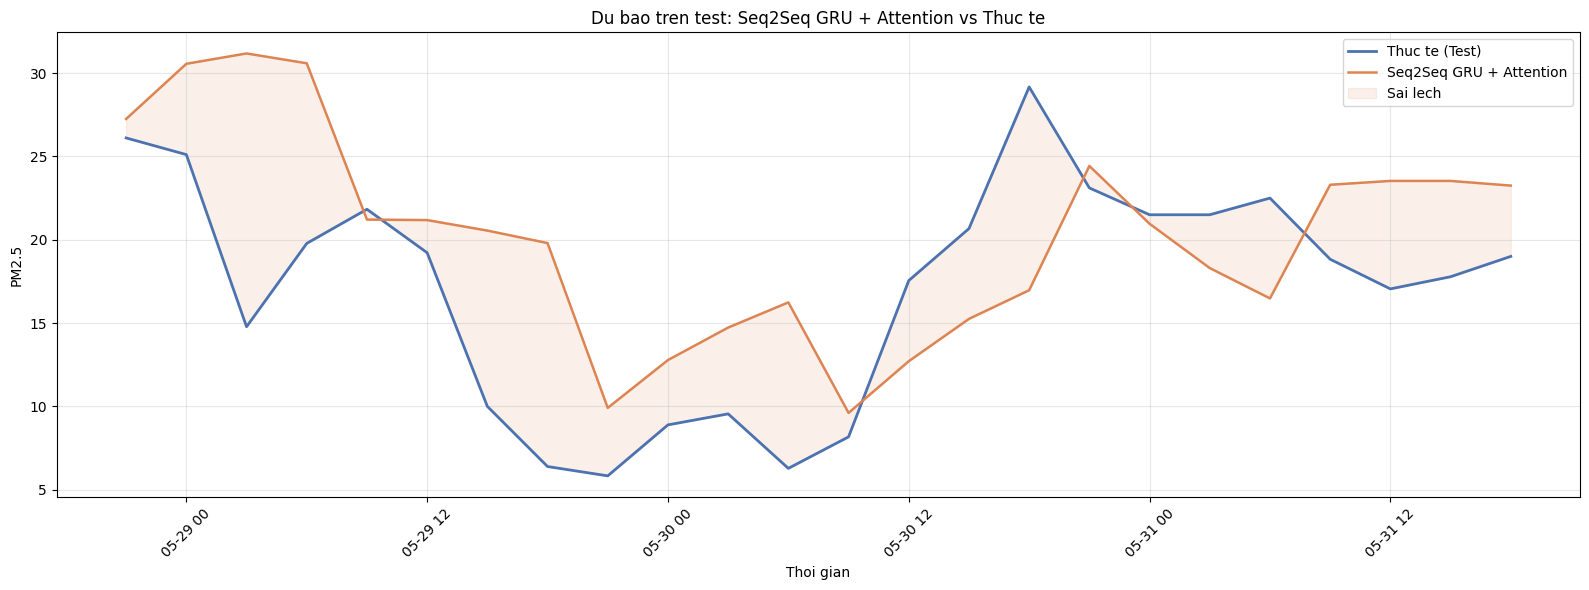

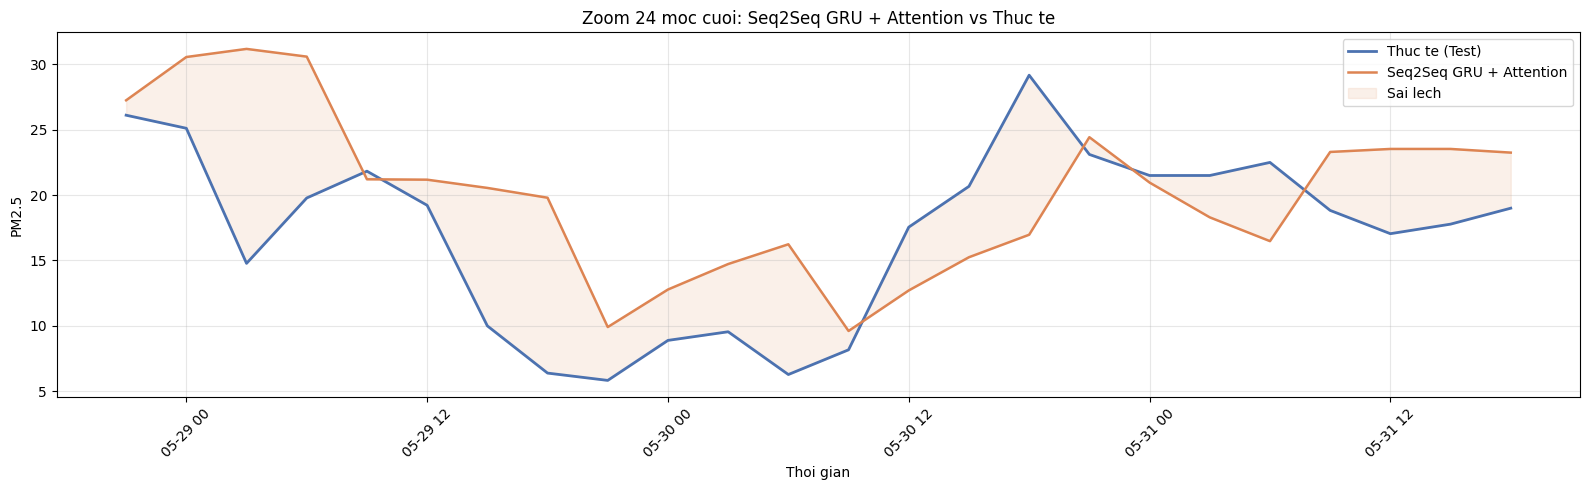

In [47]:
plot_df = prediction_table.copy()

plt.figure(figsize=(16, 6))
plt.plot(plot_df["timestamp"], plot_df["actual"], label="Thuc te (Test)", linewidth=2.0, color="#4C72B0")
plt.plot(plot_df["timestamp"], plot_df["prediction"], label=MODEL_LABEL, linewidth=1.8, color="#DD8452")
plt.fill_between(plot_df["timestamp"], plot_df["actual"], plot_df["prediction"], color="#DD8452", alpha=0.12, label="Sai lech")
plt.title(f"Du bao tren test: {MODEL_LABEL} vs Thuc te")
plt.xlabel("Thoi gian")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

zoom_n = min(200, len(plot_df))
zoom_df = plot_df.tail(zoom_n).copy()

plt.figure(figsize=(16, 5))
plt.plot(zoom_df["timestamp"], zoom_df["actual"], label="Thuc te (Test)", linewidth=2.0, color="#4C72B0")
plt.plot(zoom_df["timestamp"], zoom_df["prediction"], label=MODEL_LABEL, linewidth=1.8, color="#DD8452")
plt.fill_between(zoom_df["timestamp"], zoom_df["actual"], zoom_df["prediction"], color="#DD8452", alpha=0.12, label="Sai lech")
plt.title(f"Zoom {zoom_n} moc cuoi: {MODEL_LABEL} vs Thuc te")
plt.xlabel("Thoi gian")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

=== Sanity check ===
Rows: 24
Time range: 2025-05-28 21:00:00 -> 2025-05-31 18:00:00
Prediction columns: ['prediction']
Cyclical features in all: ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']

=== Trung binh theo gio trong ngay ===


,hour,actual,prediction
0,0,18.50,21.43
1,3,15.28,21.40
2,6,16.19,21.10
3,9,16.28,18.04
4,12,17.94,19.14
5,15,16.15,19.78
6,18,18.19,20.01
7,21,18.35,20.53



=== Trung binh theo thu trong tuan ===


,dayofweek,dow_name,actual,prediction
0,2,Wed,26.11,27.25
1,3,Thu,15.37,23.12
2,4,Fri,15.42,15.34
3,5,Sat,19.74,21.34



=== Do khop profile mua vu ===


,model,overall_bias,hour_profile_mae,hour_profile_corr,dow_profile_mae,dow_profile_corr
0,Seq2Seq GRU + Attention,3.071,3.071,0.019,2.644,0.755


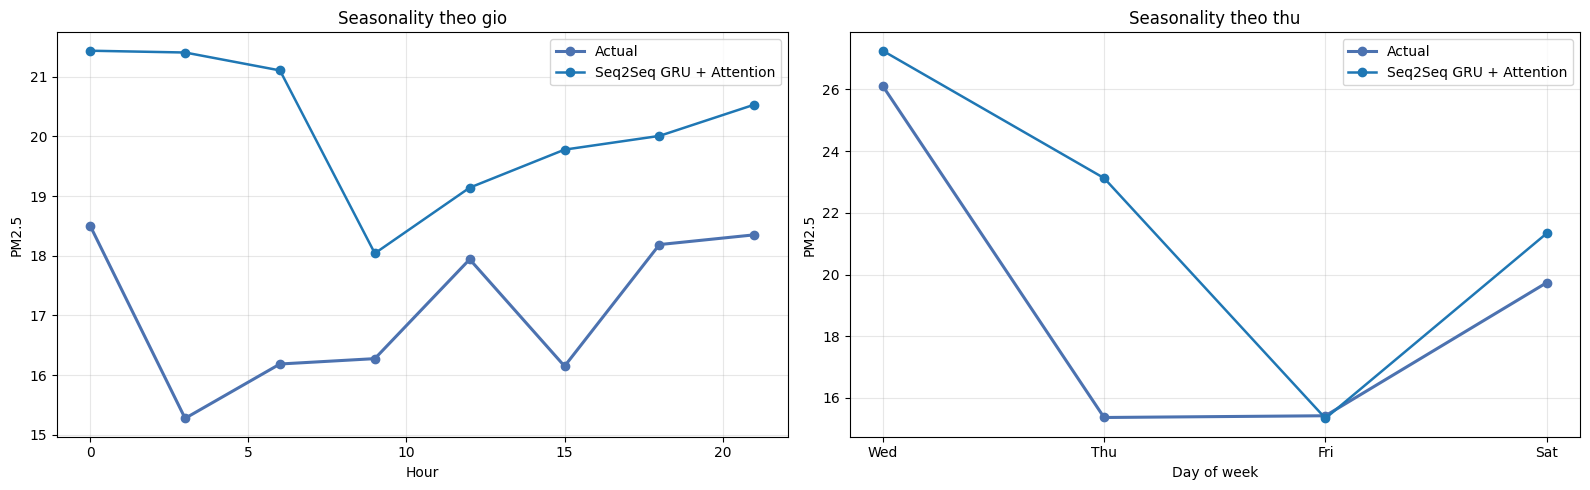

In [48]:
seasonality_df = prediction_table.copy()
seasonality_df["timestamp"] = pd.to_datetime(seasonality_df["timestamp"])
seasonality_df = seasonality_df.sort_values("timestamp").reset_index(drop=True)
seasonality_df["hour"] = seasonality_df["timestamp"].dt.hour
seasonality_df["dayofweek"] = seasonality_df["timestamp"].dt.dayofweek
seasonality_df["abs_error"] = np.nan

pred_label_map = {
    "prediction": MODEL_LABEL if "MODEL_LABEL" in globals() else "Current model",
    "seq2seq_gru": "Seq2Seq GRU",
    "seq2seq_gru_attention": "Seq2Seq GRU + Attention",
}
pred_cols = [col for col in pred_label_map if col in seasonality_df.columns]
if not pred_cols:
    raise ValueError(
        f"Khong tim thay cot du bao trong prediction_table. Columns hien co: {seasonality_df.columns.tolist()}"
    )

print("=== Sanity check ===")
print("Rows:", len(seasonality_df))
print("Time range:", seasonality_df["timestamp"].min(), "->", seasonality_df["timestamp"].max())
print("Prediction columns:", pred_cols)

cyc_cols = ["hour_sin", "hour_cos", "dow_sin", "dow_cos"]
if "candidate_feature_sets" in globals():
    used_cols = candidate_feature_sets.get("all", [])
    print("Cyclical features in :", [c for c in cyc_cols if c in used_cols])

dow_map = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}

hour_summary = seasonality_df.groupby("hour", as_index=False)[["actual"] + pred_cols].mean()
dow_summary = (
    seasonality_df.groupby("dayofweek", as_index=False)[["actual"] + pred_cols]
    .mean()
    .sort_values("dayofweek")
)
dow_summary["dow_name"] = dow_summary["dayofweek"].map(dow_map)

print("\n=== Trung binh theo gio trong ngay ===")
display(hour_summary.round(2))
print("\n=== Trung binh theo thu trong tuan ===")
display(dow_summary[["dayofweek", "dow_name", "actual"] + pred_cols].round(2))

metric_rows = []
for col in pred_cols:
    seasonality_df["abs_error"] = (seasonality_df["actual"] - seasonality_df[col]).abs()
    bias = (seasonality_df[col] - seasonality_df["actual"]).mean()

    hour_mae = np.mean(np.abs(hour_summary["actual"] - hour_summary[col]))
    dow_mae = np.mean(np.abs(dow_summary["actual"] - dow_summary[col]))

    hour_corr = hour_summary[["actual", col]].corr().iloc[0, 1]
    dow_corr = dow_summary[["actual", col]].corr().iloc[0, 1]

    metric_rows.append(
        {
            "model": pred_label_map[col],
            "overall_bias": bias,
            "hour_profile_mae": hour_mae,
            "hour_profile_corr": hour_corr,
            "dow_profile_mae": dow_mae,
            "dow_profile_corr": dow_corr,
        }
    )

seasonality_metrics_df = pd.DataFrame(metric_rows)
print("\n=== Do khop profile mua vu ===")
display(seasonality_metrics_df.round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(hour_summary["hour"], hour_summary["actual"], marker="o", linewidth=2.2, color="#4C72B0", label="Actual")
for col in pred_cols:
    axes[0].plot(hour_summary["hour"], hour_summary[col], marker="o", linewidth=1.8, label=pred_label_map[col])
axes[0].set_title("Seasonality theo gio")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("PM2.5")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(dow_summary["dow_name"], dow_summary["actual"], marker="o", linewidth=2.2, color="#4C72B0", label="Actual")
for col in pred_cols:
    axes[1].plot(dow_summary["dow_name"], dow_summary[col], marker="o", linewidth=1.8, label=pred_label_map[col])
axes[1].set_title("Seasonality theo thu")
axes[1].set_xlabel("Day of week")
axes[1].set_ylabel("PM2.5")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()
